# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [ ]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "VISl"        # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw
To: /content/datos.npz
100%|██████████| 16.6M/16.6M [00:00<00:00, 56.1MB/s]


Área: VISl  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [ ]:
import numpy as np

d = np.load('/content/datos.npz', allow_pickle=True)

n_neuronas = len(d['u_id'])                 # una fila por neurona
n_ratones  = len(np.unique(d['u_raton']))   # ratones distintos
n_pas      = len(d['s_t'])                  # una fila por potencial de acción
clases, n_ensayos = np.unique(d['e_clase'].astype(str), return_counts=True)

print(f"Neuronas en total:  {n_neuronas}")
print(f"Ratones distintos:  {n_ratones}")
print(f"PAs en total:       {n_pas:,}")
print("\nEnsayos por clase de estímulo:")
for clase, n in zip(clases, n_ensayos):
    print(f"  {clase:<25} {n}")
print(f"  {'TOTAL':<25} {n_ensayos.sum()}")

Neuronas en total:  277
Ratones distintos:  5
PAs en total:       4,153,518

Ensayos por clase de estímulo:
  drifting_gratings         2000
  flashes                   750
  natural_movie_one         40
  natural_scenes            2000
  spontaneous               750
  static_gratings           1250
  TOTAL                     6790


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [ ]:
clases_ens = d['e_clase'].astype(str)   # se guarda en una variable para no releer el archivo cada vez

idx_drifting    = np.where(clases_ens == 'drifting_gratings')[0]
idx_spontaneous = np.where(clases_ens == 'spontaneous')[0]

print(f"Ensayos drifting_gratings (rejillas en movimiento): {len(idx_drifting)}")
print(f"Ensayos spontaneous (pantalla gris):                {len(idx_spontaneous)}")

Ensayos drifting_gratings (rejillas en movimiento): 2000
Ensayos spontaneous (pantalla gris):                750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [ ]:
T_INI, T_FIN = 0.0, 2.0            # ventana (s) medida desde el inicio de cada ensayo
DUR = T_FIN - T_INI

# Cada d['...'] relee el archivo, así que se guarda todo una vez en variables
s_unidad = d['s_unidad'].astype(np.int64)   # ÍNDICE de la neurona (fila de las tablas u_*), no u_id
s_ensayo = d['s_ensayo'].astype(np.int64)   # ÍNDICE del ensayo (fila de las tablas e_*)
s_t      = d['s_t']

u_raton = d['u_raton'].astype(str)
e_raton = d['e_raton'].astype(str)
n_neuronas = len(u_raton)
n_ens_tot  = len(e_raton)

# Ratones -> códigos enteros, con la MISMA codificación para neuronas y ensayos
nombres_ratones, cod = np.unique(np.concatenate([u_raton, e_raton]), return_inverse=True)
u_cod, e_cod = cod[:n_neuronas], cod[n_neuronas:]


def tasa_por_ensayo(idx_ensayos):
    """Matriz (n_neuronas x len(idx_ensayos)) con la tasa de disparo en Hz.
    La columna j es el ensayo idx_ensayos[j]. Si la neurona no vio ese ensayo
    (porque es de otro ratón), la celda queda en NaN, no en 0."""
    n_cols = len(idx_ensayos)

    # índice de ensayo (tabla e_*) -> columna de esta matriz; -1 si es de otra clase
    col_de_ensayo = np.full(n_ens_tot, -1, dtype=np.int64)
    col_de_ensayo[idx_ensayos] = np.arange(n_cols)
    col = col_de_ensayo[s_ensayo]                    # columna de cada PA

    # PAs de esta clase de ensayo dentro de la ventana [0, 2)
    usar = (col >= 0) & (s_t >= T_INI) & (s_t < T_FIN)

    # contar PAs por (neurona, ensayo) de una sola vez
    plano = s_unidad[usar] * n_cols + col[usar]
    cuentas = np.bincount(plano, minlength=n_neuronas * n_cols).reshape(n_neuronas, n_cols)
    tasa = cuentas / DUR                             # Hz

    # emparejar ratones: cada neurona solo vio los ensayos de SU ratón
    vio = u_cod[:, None] == e_cod[idx_ensayos][None, :]
    return np.where(vio, tasa, np.nan)


tasa_evocada = tasa_por_ensayo(idx_drifting)       # rejillas en movimiento, 0-2 s
tasa_basal   = tasa_por_ensayo(idx_spontaneous)    # pantalla gris, 0-2 s


# ---------- Comprobaciones ----------
print(f"tasa_evocada: {tasa_evocada.shape}  (neuronas x ensayos drifting_gratings)")
print(f"tasa_basal:   {tasa_basal.shape}  (neuronas x ensayos spontaneous)")

# Cada PA debe pertenecer a una neurona y a un ensayo del MISMO ratón
coherente = np.array_equal(u_cod[s_unidad], e_cod[s_ensayo])
print("\nRatón de la neurona = ratón del ensayo en todos los PAs:",
      "OK" if coherente else "NO, REVISAR (s_unidad / s_ensayo mal interpretados)")
print(f"s_t va de {s_t.min():.3f} a {s_t.max():.3f} s (debería ser tiempo desde el inicio del ensayo)")

print("\nPor ratón:")
for k, nombre in enumerate(nombres_ratones):
    print(f"  {nombre:<12} neuronas: {(u_cod == k).sum():<5} "
          f"drifting: {(e_cod[idx_drifting] == k).sum():<5} "
          f"spontaneous: {(e_cod[idx_spontaneous] == k).sum()}")

print(f"\nTasa media evocada: {np.nanmean(tasa_evocada):.2f} Hz")
print(f"Tasa media basal:   {np.nanmean(tasa_basal):.2f} Hz")

tasa_evocada: (277, 2000)  (neuronas x ensayos drifting_gratings)
tasa_basal:   (277, 750)  (neuronas x ensayos spontaneous)

Ratón de la neurona = ratón del ensayo en todos los PAs: OK
s_t va de -1.000 a 31.025 s (debería ser tiempo desde el inicio del ensayo)

Por ratón:
  715093703    neuronas: 42    drifting: 400   spontaneous: 150
  756029989    neuronas: 30    drifting: 400   spontaneous: 150
  760345702    neuronas: 50    drifting: 400   spontaneous: 150
  762120172    neuronas: 77    drifting: 400   spontaneous: 150
  798911424    neuronas: 78    drifting: 400   spontaneous: 150

Tasa media evocada: 5.55 Hz
Tasa media basal:   4.95 Hz



--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [ ]:
# PASO 4: Z-score y fraccion de neuronas respondedoras
# Requiere lo que dejaron los pasos 1-3: d, idx_drifting, n_neuronas, tasa_evocada, tasa_basal

import warnings

UMBRAL_Z = 2.5     # una neurona es respondedora si su Z >= 2.5
DDOF     = 0       # desviación estándar de NumPy por defecto (poblacional); pon 1 para la muestral (n-1)

# ---------- Basal y evocada promedio (solo ensayos de SU ratón) ----------
# tasa_evocada y tasa_basal traen NaN en los ensayos de otros ratones, así que nanmean/nanstd los ignoran
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)         # neurona sin ensayos propios -> NaN (se cuentan abajo)
    mu_basal   = np.nanmean(tasa_basal, axis=1)             # basal promedio de cada neurona
    sd_basal   = np.nanstd(tasa_basal, axis=1, ddof=DDOF)   # desviación estándar de SU basal
    evoc_media = np.nanmean(tasa_evocada, axis=1)           # evocada promedio, todas las rejillas


def zscore(evocada, mu, sd):
    """(evocada - basal) / sd de la basal. Si sd es 0 o no existe, Z = NaN (no inf)."""
    z = np.full(len(evocada), np.nan)
    with np.errstate(invalid="ignore"):
        ok = sd > 0
    z[ok] = (evocada[ok] - mu[ok]) / sd[ok]
    return z


z_global = zscore(evoc_media, mu_basal, sd_basal)           # Z con todos los ensayos de rejilla juntos


# ---------- Combinaciones de estímulo: dirección x frec. temporal x frec. espacial ----------
def a_float(x):
    """A float; lo que no sea número ('null', None...) pasa a NaN."""
    x = np.asarray(x)
    if x.dtype.kind in "fiu":
        return x.astype(float)
    out = np.full(len(x), np.nan)
    for i, v in enumerate(x):
        try:
            out[i] = float(v)
        except (TypeError, ValueError):
            pass
    return out


# una fila por ensayo de rejilla, en el mismo orden que las columnas de tasa_evocada
car = np.column_stack([a_float(np.asarray(d[k])[idx_drifting])
                       for k in ('e_orientacion', 'e_frec_temporal', 'e_frec_espacial')])
tiene_car = ~np.isnan(car).any(axis=1)                      # ensayos con las 3 características definidas
if not tiene_car.any():
    raise ValueError("Ningún ensayo de rejilla tiene definidas las 3 características; "
                     "revisa e_orientacion, e_frec_temporal y e_frec_espacial")

cols_val = np.where(tiene_car)[0]                           # columnas de tasa_evocada que entran en las combinaciones
combos, etq = np.unique(car[tiene_car], axis=0, return_inverse=True)   # combos: una fila por combinación
etq = etq.ravel()                                           # combinación de cada ensayo válido
n_comb = len(combos)

# respuesta evocada de cada neurona en cada combinación (solo ensayos de su ratón)
resp  = np.full((n_neuronas, n_comb), np.nan)               # tasa evocada media (Hz)
n_ens = np.zeros((n_neuronas, n_comb), dtype=int)           # nº de ensayos propios de esa combinación
for k in range(n_comb):
    sub = tasa_evocada[:, cols_val[etq == k]]               # neuronas x ensayos de la combinación k
    n_ens[:, k] = (~np.isnan(sub)).sum(axis=1)
    resp[:, k]  = np.where(n_ens[:, k] > 0,
                           np.nansum(sub, axis=1) / np.maximum(n_ens[:, k], 1),
                           np.nan)                          # NaN si el ratón de la neurona no vio esa combinación

# condición preferida = combinación con la tasa evocada media más alta
k_pref    = np.where(np.isnan(resp), -np.inf, resp).argmax(axis=1)
resp_pref = resp[np.arange(n_neuronas), k_pref]
z_pref    = zscore(resp_pref, mu_basal, sd_basal)           # Z solo con los ensayos de la condición preferida


# ---------- Respondedoras ----------
with np.errstate(invalid="ignore"):
    n_resp_pref   = int((z_pref   >= UMBRAL_Z).sum())
    n_resp_global = int((z_global >= UMBRAL_Z).sum())
n_indef = int(np.isnan(z_pref).sum())


# ---------- Comprobaciones y resultado ----------
print(f"Ensayos de rejilla sin las 3 características definidas (fuera de las combinaciones): {int((~tiene_car).sum())}")
for j, nombre in enumerate(('direcciones', 'frec. temporales', 'frec. espaciales')):
    print(f"  {nombre:<17}: {np.unique(combos[:, j])}")
print(f"  combinaciones posibles: {n_comb}  |  ensayos propios por combinación: "
      f"mín {n_ens[n_ens > 0].min()}, máx {n_ens.max()}")
n_base = (~np.isnan(tasa_basal)).sum(axis=1)
print(f"Ensayos basales por neurona: mín {n_base.min()}, máx {n_base.max()}")
print(f"Neuronas con Z indefinido (basal sin variación o sin ensayos): {n_indef} de {n_neuronas}")

print(f"\nReferencia, Z con todas las rejillas juntas: {n_resp_global} neuronas con Z >= {UMBRAL_Z} "
      f"({100 * n_resp_global / n_neuronas:.1f} %)")
print(f"Neuronas con Z >= {UMBRAL_Z} en su condición preferida: {n_resp_pref} de {n_neuronas}")
print(f"Fracción respondedora: {100 * n_resp_pref / n_neuronas:.1f} %")

Ensayos de rejilla sin las 3 características definidas (fuera de las combinaciones): 95
  direcciones      : [  0.  45.  90. 135. 180. 225. 270. 315.]
  frec. temporales : [ 1.  2.  4.  8. 15.]
  frec. espaciales : [0.04]
  combinaciones posibles: 40  |  ensayos propios por combinación: mín 9, máx 10
Ensayos basales por neurona: mín 150, máx 150
Neuronas con Z indefinido (basal sin variación o sin ensayos): 0 de 277

Referencia, Z con todas las rejillas juntas: 20 neuronas con Z >= 2.5 (7.2 %)
Neuronas con Z >= 2.5 en su condición preferida: 128 de 277
Fracción respondedora: 46.2 %


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [ ]:
ratones_unicos = np.unique(u_raton)

print("Fracción de neuronas respondedoras por ratón (en su condición preferida):\n")

for raton in ratones_unicos:
    # Máscara para filtrar solo las neuronas pertenecientes a este ratón
    mask_raton = (u_raton == raton)

    n_neuronas_raton = mask_raton.sum()

    # Evaluar Z-score preferido en las neuronas de este ratón
    z_raton = z_pref[mask_raton]

    with np.errstate(invalid="ignore"):
        n_resp_raton = int((z_raton >= UMBRAL_Z).sum())

    fraccion_raton = (n_resp_raton / n_neuronas_raton) * 100

    print(f"  Ratón {raton}: {n_resp_raton:2d} / {n_neuronas_raton:2d} neuronas ({fraccion_raton:5.1f} %)")

Fracción de neuronas respondedoras por ratón (en su condición preferida):

  Ratón 715093703: 24 / 42 neuronas ( 57.1 %)
  Ratón 756029989: 16 / 30 neuronas ( 53.3 %)
  Ratón 760345702: 32 / 50 neuronas ( 64.0 %)
  Ratón 762120172: 21 / 77 neuronas ( 27.3 %)
  Ratón 798911424: 35 / 78 neuronas ( 44.9 %)


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

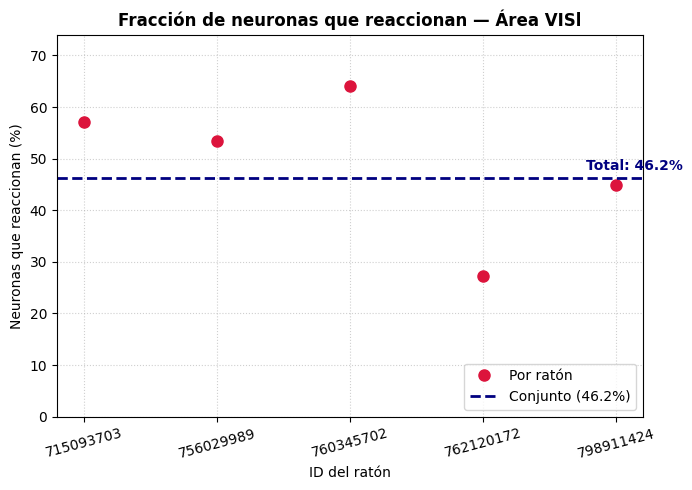

In [ ]:
# PASO 6: La gráfica
# Grafica la fracción de neuronas respondedoras por ratón y la fracción global

import matplotlib.pyplot as plt

# 1. Calcular las fracciones por ratón para graficar
ratones_unicos = np.unique(u_raton)
fracciones_ratones = []

for raton in ratones_unicos:
    mask_raton = (u_raton == raton)
    z_raton = z_pref[mask_raton]
    with np.errstate(invalid="ignore"):
        n_resp_raton = (z_raton >= UMBRAL_Z).sum()
    frac_raton = (n_resp_raton / mask_raton.sum()) * 100
    fracciones_ratones.append(frac_raton)

# Fracción global del conjunto (calculada en el Paso 4)
fraccion_conjunto = (n_resp_pref / n_neuronas) * 100

# 2. Generar la figura
plt.figure(figsize=(7, 5))

# Puntos por cada ratón
plt.plot(ratones_unicos, fracciones_ratones, 'o', color='crimson', markersize=8, label='Por ratón')

# Línea horizontal con la fracción del conjunto global
plt.axhline(y=fraccion_conjunto, color='navy', linestyle='--', linewidth=2, label=f'Conjunto ({fraccion_conjunto:.1f}%)')

# Texto con el número del conjunto dentro de la figura
plt.text(len(ratones_unicos) - 0.5, fraccion_conjunto + 1.5,
         f'Total: {fraccion_conjunto:.1f}%',
         color='navy', fontweight='bold', fontsize=10, ha='right')

# Rotulado de ejes, título y formato
plt.title(f'Fracción de neuronas que reaccionan — Área {MI_AREA}', fontsize=12, fontweight='bold')
plt.xlabel('ID del ratón', fontsize=10)
plt.ylabel('Neuronas que reaccionan (%)', fontsize=10)
plt.xticks(rotation=15)
plt.ylim(0, max(max(fracciones_ratones), fraccion_conjunto) + 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.

Fracción respondedora: 46.2 % (correspondiente a 128 de 277 neuronas con $Z \ge 2.5$ en su condición preferida).

## Proyecto final

Figura 1C

In [ ]:
# comprobación de los datos

print("Número de neuronas:", len(d["u_id"]))
print("Número de PAs:", len(d["s_t"]))
print("\nPrimeros IDs de neuronas:")
print(d["u_id"][:10])
print("\nPrimeros ratones:")
print(d["u_raton"][:10])
print("\nRango de tiempos de los PAs:")
print(d["s_t"].min(), d["s_t"].max())

Número de neuronas: 277
Número de PAs: 4153518

Primeros IDs de neuronas:
[951881575 951881457 951879060 951879018 951879000 951880046 951880033
 951881384 951878139 951879902]

Primeros ratones:
[762120172 762120172 762120172 762120172 762120172 762120172 762120172
 762120172 762120172 762120172]

Rango de tiempos de los PAs:
-0.99996513 31.025064


In [ ]:
#Confirmación de variables
print("Variables disponibles:")
print(list(d.keys()))

Variables disponibles:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


In [ ]:
# FIGURA 1A — explorar las formas de onda

print("Tipo de u_onda:", type(d["u_onda"]))
print("Shape de u_onda:", np.shape(d["u_onda"]))
print("Número de neuronas:", len(d["u_id"]))
print("\nForma de onda de la primera neurona:")
print(d["u_onda"][0])
print("\nNúmero de muestras de la waveform:")
print(len(d["u_onda"][0]))

Tipo de u_onda: <class 'numpy.ndarray'>
Shape de u_onda: (277, 7, 82)
Número de neuronas: 277

Forma de onda de la primera neurona:
[[ 0.0000000e+00 -1.3560300e+00 -1.9722300e+00 -1.8056999e+00
  -1.2000300e+00 -1.5662400e+00 -1.9722300e+00 -1.5701400e+00
  -2.1231599e+00 -1.0506600e+00 -1.9262100e+00 -1.6637400e+00
  -5.0621998e-01 -2.0689499e+00 -2.8711801e+00 -5.5243502e+00
  -7.4365201e+00 -7.2579002e+00 -8.4739199e+00 -4.1687102e+00
  -6.0918002e+00 -7.9349399e+00 -8.9816999e+00 -1.0596300e+01
  -9.1400404e+00 -7.0445700e+00 -4.9019098e+00 -2.9086201e+00
  -1.3310699e+00  1.7230200e+00  2.0003099e+00  4.0907102e+00
   6.1222200e+00  6.8862300e+00  8.4138603e+00  8.9785805e+00
   1.0008570e+01  1.0084620e+01  8.8740597e+00  9.9040499e+00
   8.8857603e+00  9.0300598e+00  9.3720903e+00  8.0913296e+00
   7.8027301e+00  6.9443402e+00  6.4034100e+00  5.9123998e+00
   4.9998002e+00  4.3691702e+00  3.9066300e+00  3.4542301e+00
   2.8512900e+00  3.0423901e+00  3.5661600e+00  2.8376400e+00


In [ ]:
# Calidad de la neurona

print("Firing rate:")
print(d["u_firing_rate"][:10])
print("\nSNR:")
print(d["u_snr"][:10])
print("\nPresence ratio:")
print(d["u_presence_ratio"][:10])
print("\nISI violations:")
print(d["u_isi_violations"][:10])
print("\nAmplitude cutoff:")
print(d["u_amplitude_cutoff"][:10])

Firing rate:
[ 0.33905565  7.43398268  9.38645202  0.36692858  3.79997665 10.77074245
  1.5940196   0.27249198  1.14337478  3.36775135]

SNR:
[3.31677121 2.67164408 2.42316677 2.08000473 5.36581794 4.66185146
 3.92530987 1.69570038 3.15070353 1.22571106]

Presence ratio:
[0.91 0.99 0.99 0.99 0.99 0.99 0.99 0.96 0.98 0.99]

ISI violations:
[3.17752344e-01 2.37952428e-02 7.91883268e-02 0.00000000e+00
 2.52969914e-03 3.14875918e-04 4.31285316e-01 0.00000000e+00
 1.67650465e-01 4.28353511e-01]

Amplitude cutoff:
[0.01364689 0.03256846 0.00680071 0.07778178 0.00044943 0.00023994
 0.00691612 0.0142899  0.03379086 0.0175452 ]


In [ ]:
# información de ensayos
print("Número de ensayos:", len(d["e_clase"]))
print("\nPrimeros 10 ensayos:")
for i in range(10):
    print(
        i,
        "clase =", d["e_clase"][i],
        "ratón =", d["e_raton"][i],
        "t0 =", d["e_t0"][i],
        "dur =", d["e_dur"][i],
        "orientación =", d["e_orientacion"][i],
        "frec temporal =", d["e_frec_temporal"][i],
        "frec espacial =", d["e_frec_espacial"][i]
    )

Número de ensayos: 6790

Primeros 10 ensayos:
0 clase = drifting_gratings ratón = 762120172 t0 = 1598.9540042142958 dur = 2.00164 orientación = 225.0 frec temporal = 15.0 frec espacial = 0.04
1 clase = drifting_gratings ratón = 762120172 t0 = 1601.9565067924145 dur = 2.00167 orientación = 45.0 frec temporal = 2.0 frec espacial = 0.04
2 clase = drifting_gratings ratón = 762120172 t0 = 1604.9590342142956 dur = 2.00165 orientación = 135.0 frec temporal = 2.0 frec espacial = 0.04
3 clase = drifting_gratings ratón = 762120172 t0 = 1607.9615167924146 dur = 2.00168 orientación = 0.0 frec temporal = 4.0 frec espacial = 0.04
4 clase = drifting_gratings ratón = 762120172 t0 = 1610.9640442142954 dur = 2.00166 orientación = 270.0 frec temporal = 2.0 frec espacial = 0.04
5 clase = drifting_gratings ratón = 762120172 t0 = 1613.9665367924144 dur = 2.00166 orientación = 90.0 frec temporal = 1.0 frec espacial = 0.04
6 clase = drifting_gratings ratón = 762120172 t0 = 1619.9715567924145 dur = 2.00168 ori

In [ ]:
#relacion spikes neuroa y ensayos
print("Número total de spikes:", len(d["s_t"]))
print("Primeros 20 spikes:")
for i in range(20):
    print(
        i,
        "unidad =", d["s_unidad"][i],
        "ensayo =", d["s_ensayo"][i],
        "tiempo =", d["s_t"][i]
    )
print("\nRango de unidades en s_unidad:",
      np.min(d["s_unidad"]),
      np.max(d["s_unidad"]))
print("Rango de ensayos en s_ensayo:",
      np.min(d["s_ensayo"]),
      np.max(d["s_ensayo"]))

Número total de spikes: 4153518
Primeros 20 spikes:
0 unidad = 0 ensayo = 969 tiempo = 0.82215977
1 unidad = 0 ensayo = 504 tiempo = 0.67295253
2 unidad = 0 ensayo = 509 tiempo = -0.053076454
3 unidad = 0 ensayo = 544 tiempo = 0.7129194
4 unidad = 0 ensayo = 3 tiempo = 1.1610088
5 unidad = 0 ensayo = 3 tiempo = 2.0387444
6 unidad = 0 ensayo = 5 tiempo = 1.9342067
7 unidad = 0 ensayo = 6 tiempo = 0.4134651
8 unidad = 0 ensayo = 6 tiempo = 1.536568
9 unidad = 0 ensayo = 10 tiempo = 0.33807218
10 unidad = 0 ensayo = 11 tiempo = 1.5387424
11 unidad = 0 ensayo = 12 tiempo = 0.709898
12 unidad = 0 ensayo = 14 tiempo = 0.19692574
13 unidad = 0 ensayo = 16 tiempo = 0.06433161
14 unidad = 0 ensayo = 22 tiempo = 1.098356
15 unidad = 0 ensayo = 25 tiempo = 0.4350515
16 unidad = 0 ensayo = 25 tiempo = 0.8233192
17 unidad = 0 ensayo = 29 tiempo = 0.43486682
18 unidad = 0 ensayo = 29 tiempo = 0.66230077
19 unidad = 0 ensayo = 41 tiempo = 0.06462387

Rango de unidades en s_unidad: 0 276
Rango de ensa

In [ ]:
#estructura de la forma de la onda
u_onda = d["u_onda"]
print("Shape:", u_onda.shape)
print("\nNúmero de neuronas:", u_onda.shape[0])
print("Número de waveforms por neurona:", u_onda.shape[1])
print("Número de muestras temporales:", u_onda.shape[2])
# Estadísticos de la primera neurona
print("\nPrimera neurona:")
print("mínimo:", np.min(u_onda[0]))
print("máximo:", np.max(u_onda[0]))
print("media:", np.mean(u_onda[0]))
print("desviación:", np.std(u_onda[0]))
# Ver si las 7 waveforms de la primera neurona son diferentes
for i in range(7):
    print(
        f"Waveform {i}: "
        f"min={u_onda[0,i].min():.3f}, "
        f"max={u_onda[0,i].max():.3f}, "
        f"media={u_onda[0,i].mean():.3f}"
    )

Shape: (277, 7, 82)

Número de neuronas: 277
Número de waveforms por neurona: 7
Número de muestras temporales: 82

Primera neurona:
mínimo: -108.36384
máximo: 61.39536
media: 3.8897088
desviación: 19.421612
Waveform 0: min=-10.596, max=10.085, media=1.091
Waveform 1: min=-59.181, max=44.928, media=6.105
Waveform 2: min=-23.269, max=23.864, media=5.474
Waveform 3: min=-108.364, max=61.395, media=7.190
Waveform 4: min=-5.020, max=2.078, media=-1.085
Waveform 5: min=-95.998, max=52.010, media=6.011
Waveform 6: min=-31.897, max=20.271, media=2.442


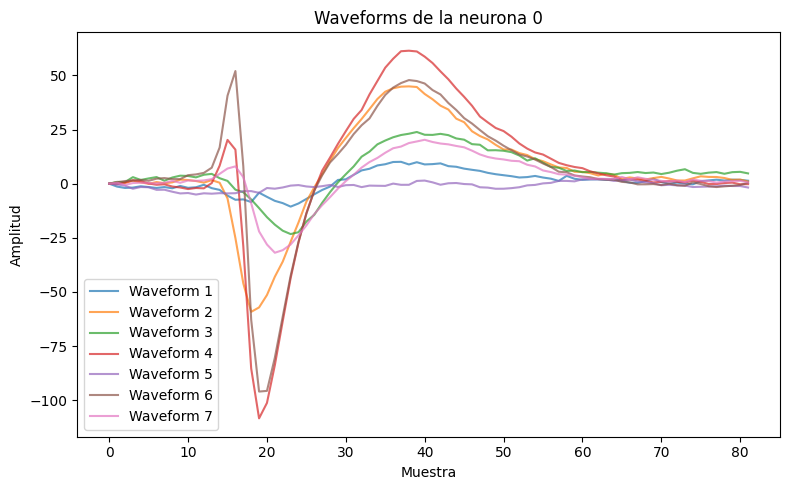

In [ ]:
# graficos de las 7 formas de onda
import matplotlib.pyplot as plt
import numpy as np

neurona_demo = 0
plt.figure(figsize=(8, 5))
for i in range(u_onda.shape[1]):
    plt.plot(
        u_onda[neurona_demo, i],
        alpha=0.7,
        label=f"Waveform {i+1}"
    )

plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.title(f"Waveforms de la neurona {neurona_demo}")
plt.legend()
plt.tight_layout()
plt.show()

Este paso anterior se hizo para ver si la forma era similar para poder simplemente sacar la onda promedio de la neurona. Pero como se ve en este caso los rangos que hay son muy diferentes entre si, por lo cual hay que realizar otra aproximación para la waveform general de la neurona.

Figura 1D

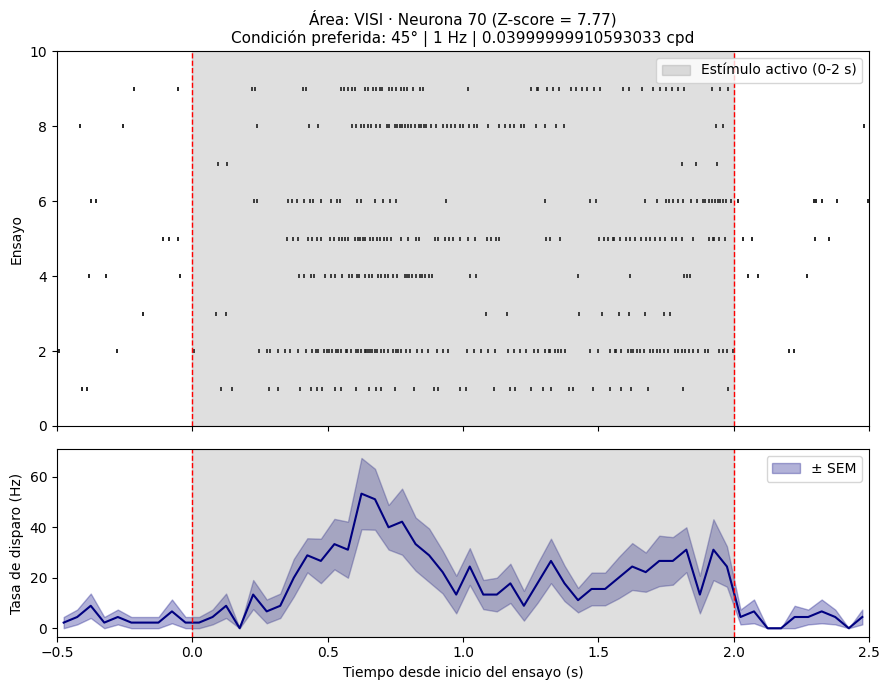

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definir una neurona de ejemplo y sus datos para la visualización
i_ejemplo = 70   # Se elige una neurona de ejemplo (puedes cambiar este índice)

# Obtener la condición preferida para la neurona de ejemplo
k_pref_neu = k_pref[i_ejemplo]

# Obtener el Z-score de la neurona de ejemplo
z_val = z_pref[i_ejemplo]

# Obtener el ratón al que pertenece la neurona de ejemplo
raton_ejemplo = u_raton[i_ejemplo]

# Obtener las características de la condición preferida
ori_pref, ft_pref, fe_pref = combos[k_pref_neu]

# Ensayos de la condición preferida, del ratón de esta neurona
cols_condicion = np.where(etq == k_pref_neu)[0]
idx_ensayos_cond = idx_drifting[cols_val[cols_condicion]]
idx_ensayos_pref = [ens for ens in idx_ensayos_cond if e_raton[ens] == raton_ejemplo]
n_ensayos_pref = len(idx_ensayos_pref)
ensayo_a_fila = {ens: fila for fila, ens in enumerate(idx_ensayos_pref)}

mask_spikes = (s_unidad == i_ejemplo) & np.isin(s_ensayo, idx_ensayos_pref)
spikes_t = s_t[mask_spikes]
spikes_filas = np.array([ensayo_a_fila[e] for e in s_ensayo[mask_spikes]])

T_MIN, T_MAX = -0.5, 2.5
BIN_SIZE = 0.05
n_bins = round((T_MAX - T_MIN) / BIN_SIZE)
bins = np.linspace(T_MIN, T_MAX, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

mask_win = (spikes_t >= T_MIN) & (spikes_t <= T_MAX)
spikes_t_win = spikes_t[mask_win]
spikes_filas_win = spikes_filas[mask_win]

# tasa por ENSAYO individual y por bin (matriz ensayos x bins), para poder sacar el SEM
fila_bins = np.arange(n_ensayos_pref + 1) - 0.5
H, _, _ = np.histogram2d(spikes_filas_win, spikes_t_win, bins=[fila_bins, bins])
tasa_por_ensayo_bin = H / BIN_SIZE          # Hz, una fila por ensayo

psth_media = tasa_por_ensayo_bin.mean(axis=0)
psth_sem   = tasa_por_ensayo_bin.std(axis=0, ddof=1) / np.sqrt(n_ensayos_pref)

fig, (ax_raster, ax_psth) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]}
)

ax_raster.scatter(spikes_t_win, spikes_filas_win + 1, color='black', s=12, marker='|', linewidths=1.2)
ax_raster.axvspan(0.0, 2.0, color='gray', alpha=0.25, label='Estímulo activo (0-2 s)')
ax_raster.axvline(0.0, color='red', linestyle='--', linewidth=1)
ax_raster.axvline(2.0, color='red', linestyle='--', linewidth=1)
ax_raster.set_ylabel('Ensayo')
ax_raster.set_ylim(0, n_ensayos_pref + 1)
ax_raster.set_title(
    f"Área: {MI_AREA} · Neurona {i_ejemplo} (Z-score = {z_val:.2f})\n"
    f"Condición preferida: {ori_pref:.0f}° | {ft_pref:.0f} Hz | {fe_pref} cpd",
    fontsize=11
)
ax_raster.legend(loc='upper right')

ax_psth.plot(bin_centers, psth_media, color='navy', linewidth=1.5)
ax_psth.fill_between(bin_centers, psth_media - psth_sem, psth_media + psth_sem,
                      color='navy', alpha=0.3, label='± SEM')
ax_psth.axvspan(0.0, 2.0, color='gray', alpha=0.25)
ax_psth.axvline(0.0, color='red', linestyle='--', linewidth=1)
ax_psth.axvline(2.0, color='red', linestyle='--', linewidth=1)
ax_psth.set_xlabel('Tiempo desde inicio del ensayo (s)')
ax_psth.set_ylabel('Tasa de disparo (Hz)')
ax_psth.set_xlim(T_MIN, T_MAX)
ax_psth.legend(loc='upper right')

plt.tight_layout()
plt.show()

Figura 2A


Neuronas incluidas: 277  ·  bins: 60 (50 ms c/u)
Tasa poblacional máxima: 9.0 Hz
Fracción respondedora (rejillas en movimiento vs espontáneo): 46.2 %


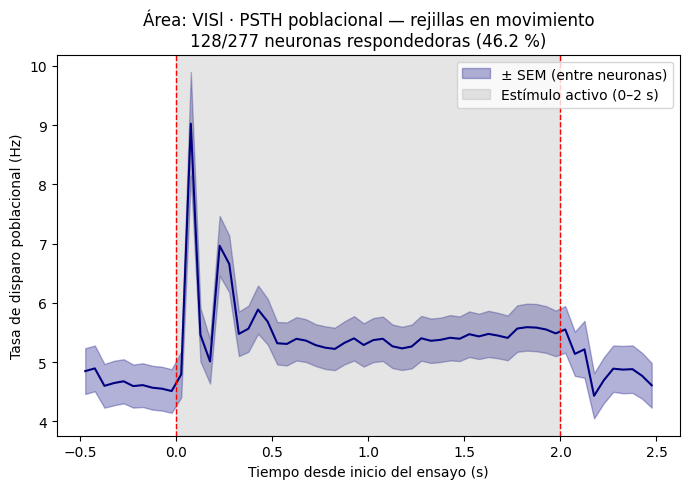

In [ ]:
# FIGURA 2A — PSTH poblacional a rejillas en movimiento (drifting_gratings)
T_MIN, T_MAX = -0.5, 2.5
BIN_SIZE = 0.05
n_bins = round((T_MAX - T_MIN) / BIN_SIZE)
bins = np.linspace(T_MIN, T_MAX, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
# Cuántos ensayos tiene cada neurona
e_cod_drift = e_cod[idx_drifting]
vio = u_cod[:, None] == e_cod_drift[None, :]
n_ensayos_propios = vio.sum(axis=1)

if (n_ensayos_propios == 0).any():
    print(f"Aviso: {int((n_ensayos_propios == 0).sum())} neuronas sin ensayos propios de rejilla")

# Filtrar los PAs: solo a los de ensayos de rejilla, dentro de la ventana
es_drift = np.isin(s_ensayo, idx_drifting)
en_ventana = (s_t >= T_MIN) & (s_t < T_MAX)
usar = es_drift & en_ventana
unidad_usar = s_unidad[usar]
t_usar      = s_t[usar]
bin_idx     = np.clip(np.digitize(t_usar, bins) - 1, 0, n_bins - 1)

# Conteo de PAs por (neurona, bin)
plano = unidad_usar * n_bins + bin_idx
cuentas = np.bincount(plano, minlength=n_neuronas * n_bins).reshape(n_neuronas, n_bins)

with np.errstate(invalid="ignore", divide="ignore"):
    tasa_neurona_bin = cuentas / (n_ensayos_propios[:, None] * BIN_SIZE)
tasa_neurona_bin[n_ensayos_propios == 0, :] = np.nan   # neuronas sin ensayos propios -> NaN
psth_media = np.nanmean(tasa_neurona_bin, axis=0)
psth_sem   = np.nanstd(tasa_neurona_bin, axis=0, ddof=1) / np.sqrt((~np.isnan(tasa_neurona_bin)).sum(axis=0))
frac_resp = 100 * n_resp_pref / n_neuronas

# Comprobación
print(f"Neuronas incluidas: {n_neuronas}  ·  bins: {n_bins} ({BIN_SIZE*1000:.0f} ms c/u)")
print(f"Tasa poblacional máxima: {np.nanmax(psth_media):.1f} Hz")
print(f"Fracción respondedora (rejillas en movimiento vs espontáneo): {frac_resp:.1f} %")

# Gráfica
plt.figure(figsize=(7, 5))
plt.plot(bin_centers, psth_media, color='navy', linewidth=1.5)
plt.fill_between(bin_centers, psth_media - psth_sem, psth_media + psth_sem,
                  color='navy', alpha=0.3, label='± SEM (entre neuronas)')
plt.axvspan(0.0, 2.0, color='gray', alpha=0.2, label='Estímulo activo (0–2 s)')
plt.axvline(0.0, color='red', linestyle='--', linewidth=1)
plt.axvline(2.0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Tiempo desde inicio del ensayo (s)')
plt.ylabel('Tasa de disparo poblacional (Hz)')
plt.title(f'Área: {MI_AREA} · PSTH poblacional — rejillas en movimiento\n'
          f'{n_resp_pref}/{n_neuronas} neuronas respondedoras ({frac_resp:.1f} %)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Figura 2B

In [ ]:
# FIGURA 2B — PSTH poblacional
# agrupando por ventana de tiempo del estímulo (misma duración)
e_clase_str = d['e_clase'].astype(str)
e_dur       = d['e_dur'].astype(float)
clases_unicas = np.unique(e_clase_str)
# duración representativa de cada clase (mediana, por si hay pequeñas variaciones)
dur_por_clase = {c: np.median(e_dur[e_clase_str == c]) for c in clases_unicas}
print("Duración por clase de estímulo:")
for c, dur in dur_por_clase.items():
    print(f"  {c:<20} {dur:.2f} s  (n={np.sum(e_clase_str == c)})")

# agrupar clases con la misa duración
grupos = {}
for c, dur in dur_por_clase.items():
    key = round(dur, 2)
    grupos.setdefault(key, []).append(c)
print("\nGrupos por ventana de tiempo:")
for dur, clases in sorted(grupos.items()):
    print(f"  {dur:.2f} s: {clases}")




Duración por clase de estímulo:
  drifting_gratings    2.00 s  (n=2000)
  flashes              0.25 s  (n=750)
  natural_movie_one    30.03 s  (n=40)
  natural_scenes       0.25 s  (n=2000)
  spontaneous          2.00 s  (n=750)
  static_gratings      0.25 s  (n=1250)

Grupos por ventana de tiempo:
  0.25 s: [np.str_('flashes'), np.str_('natural_scenes'), np.str_('static_gratings')]
  2.00 s: [np.str_('drifting_gratings'), np.str_('spontaneous')]
  30.03 s: [np.str_('natural_movie_one')]


In [ ]:
def psth_poblacional(idx_ensayos, t_min, t_max, bin_size):
    n_bins = round((t_max - t_min) / bin_size)
    bins = np.linspace(t_min, t_max, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    e_cod_sub = e_cod[idx_ensayos]
    vio = u_cod[:, None] == e_cod_sub[None, :]
    n_ensayos_propios = vio.sum(axis=1)
    es_clase   = np.isin(s_ensayo, idx_ensayos)
    en_ventana = (s_t >= t_min) & (s_t < t_max)
    usar = es_clase & en_ventana
    unidad_usar = s_unidad[usar]
    t_usar      = s_t[usar]
    bin_idx     = np.clip(np.digitize(t_usar, bins) - 1, 0, n_bins - 1)
    plano = unidad_usar * n_bins + bin_idx
    cuentas = np.bincount(plano, minlength=n_neuronas * n_bins).reshape(n_neuronas, n_bins)
    with np.errstate(invalid="ignore", divide="ignore"):
        tasa = cuentas / (n_ensayos_propios[:, None] * bin_size)
    tasa[n_ensayos_propios == 0, :] = np.nan
    media = np.nanmean(tasa, axis=0)
    sem   = np.nanstd(tasa, axis=0, ddof=1) / np.sqrt((~np.isnan(tasa)).sum(axis=0))
    return bin_centers, media, sem


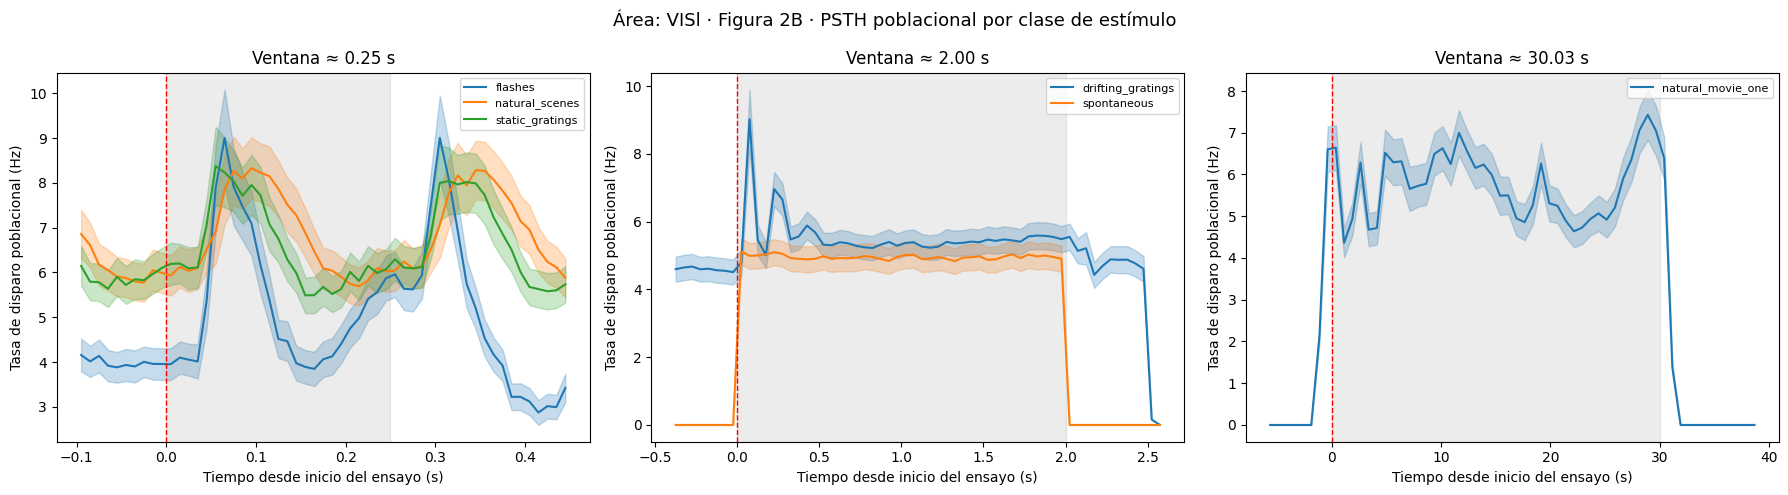

In [ ]:
# Gráfica
n_grupos = len(grupos)
fig, axes = plt.subplots(1, n_grupos, figsize=(6 * n_grupos, 5), squeeze=False)
axes = axes[0]
colores = plt.cm.tab10.colors
for ax, (dur, clases) in zip(axes, sorted(grupos.items())):
    t_min = -0.2 * dur if dur >= 1 else -0.1     # ventana proporcional a la duración
    t_max = dur + max(0.3 * dur, 0.2)
    bin_size = max(dur / 40, 0.01)
    for i, clase in enumerate(clases):
        idx_clase = np.where(e_clase_str == clase)[0]
        if len(idx_clase) == 0:
            continue
        centros, media, sem = psth_poblacional(idx_clase, t_min, t_max, bin_size)
        color = colores[i % len(colores)]
        ax.plot(centros, media, color=color, linewidth=1.5, label=clase)
        ax.fill_between(centros, media - sem, media + sem, color=color, alpha=0.25)
    ax.axvspan(0.0, dur, color='gray', alpha=0.15)
    ax.axvline(0.0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Tiempo desde inicio del ensayo (s)')
    ax.set_ylabel('Tasa de disparo poblacional (Hz)')
    ax.set_title(f'Ventana ≈ {dur:.2f} s')
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle(f'Área: {MI_AREA} · Figura 2B · PSTH poblacional por clase de estímulo', fontsize=13)
plt.tight_layout()
plt.show()

Figura 2C


In [ ]:
# Z-score de cada neurona contra su propia basal
e_clase_str = d['e_clase'].astype(str)
e_dur       = d['e_dur'].astype(float)
clases_estimulo = sorted(c for c in np.unique(e_clase_str) if c != 'spontaneous')
dur_por_clase = {c: np.median(e_dur[e_clase_str == c]) for c in clases_estimulo}
print("Clases de estímulo y su ventana:")
for c in clases_estimulo:
    print(f"  {c:<20} dur={dur_por_clase[c]:.2f} s")

Clases de estímulo y su ventana:
  drifting_gratings    dur=2.00 s
  flashes              dur=0.25 s
  natural_movie_one    dur=30.03 s
  natural_scenes       dur=0.25 s
  static_gratings      dur=0.25 s


In [ ]:
def tasa_evocada_ventana(idx_ensayos, dur):
    e_cod_sub = e_cod[idx_ensayos]
    n_cols = len(idx_ensayos)
    col_de_ensayo = np.full(n_ens_tot, -1, dtype=np.int64)
    col_de_ensayo[idx_ensayos] = np.arange(n_cols)
    col = col_de_ensayo[s_ensayo]
    usar = (col >= 0) & (s_t >= 0.0) & (s_t < dur)
    plano = s_unidad[usar] * n_cols + col[usar]
    cuentas = np.bincount(plano, minlength=n_neuronas * n_cols).reshape(n_neuronas, n_cols)
    tasa = cuentas / dur
    vio = u_cod[:, None] == e_cod_sub[None, :]
    tasa_propia = np.where(vio, tasa, np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmean(tasa_propia, axis=1)   # una tasa media por neurona

In [ ]:
# Matriz Z: neuronas x clases
Z_heatmap = np.full((n_neuronas, len(clases_estimulo)), np.nan)
for j, clase in enumerate(clases_estimulo):
    idx_clase = np.where(e_clase_str == clase)[0]
    evoc = tasa_evocada_ventana(idx_clase, dur_por_clase[clase])
    Z_heatmap[:, j] = zscore(evoc, mu_basal, sd_basal)   # zscore() ya definida en el Paso 4
# Comprobación
print(f"\nMatriz Z: {Z_heatmap.shape[0]} neuronas x {Z_heatmap.shape[1]} clases")
print(f"Rango de Z: {np.nanmin(Z_heatmap):.1f} a {np.nanmax(Z_heatmap):.1f}")
print(f"NaN en la matriz: {np.isnan(Z_heatmap).sum()} de {Z_heatmap.size}")


Matriz Z: 277 neuronas x 5 clases
Rango de Z: -1.9 a 36.4
NaN en la matriz: 0 de 1385


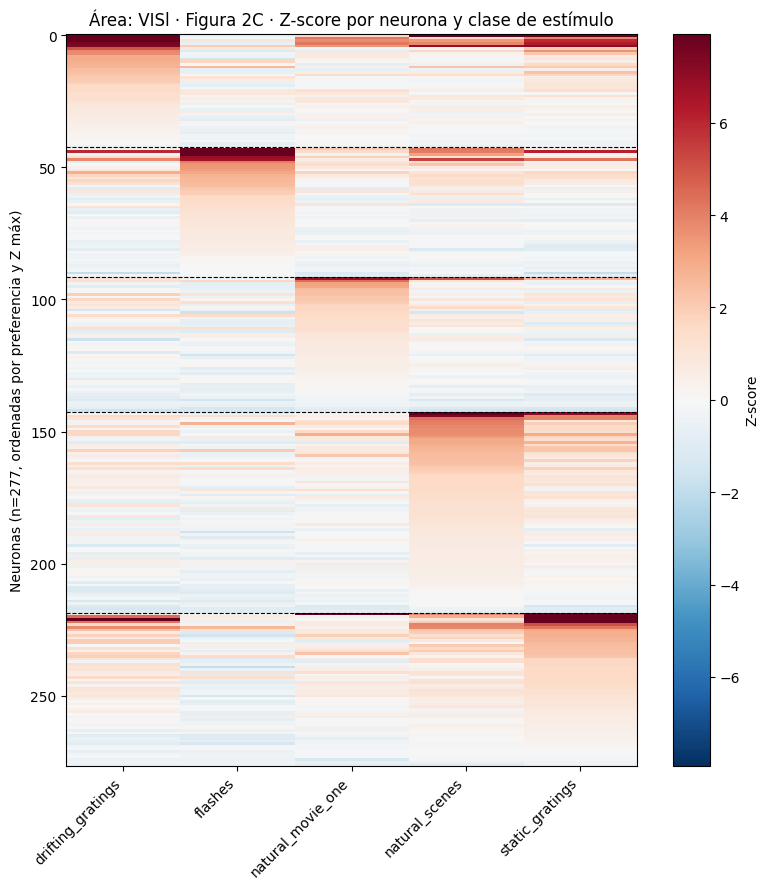

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Identificar cuál es el estímulo preferido de cada neurona (índice de la columna con max Z)
estimulo_preferido = np.nanargmax(Z_heatmap, axis=1)

# 2. Obtener el valor máximo en esa columna preferida
max_z = np.nanmax(Z_heatmap, axis=1)

# 3. Ordenar primero por la columna preferida y luego por la magnitud del Z-score
orden = np.lexsort((-max_z, estimulo_preferido))

Z_ordenado = Z_heatmap[orden]

# Graficar
plt.figure(figsize=(8, 9))
vmax = np.nanpercentile(np.abs(Z_heatmap), 99)

im = plt.imshow(Z_ordenado, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='none')
plt.colorbar(im, label='Z-score')

plt.xticks(range(len(clases_estimulo)), clases_estimulo, rotation=45, ha='right')
plt.ylabel(f'Neuronas (n={n_neuronas}, ordenadas por preferencia y Z máx)')
plt.title(f'Área: {MI_AREA} · Figura 2C · Z-score por neurona y clase de estímulo')


cambios = np.where(np.diff(estimulo_preferido[orden]))[0]
for cambio in cambios:
    plt.axhline(cambio + 0.5, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

Figura 2-D

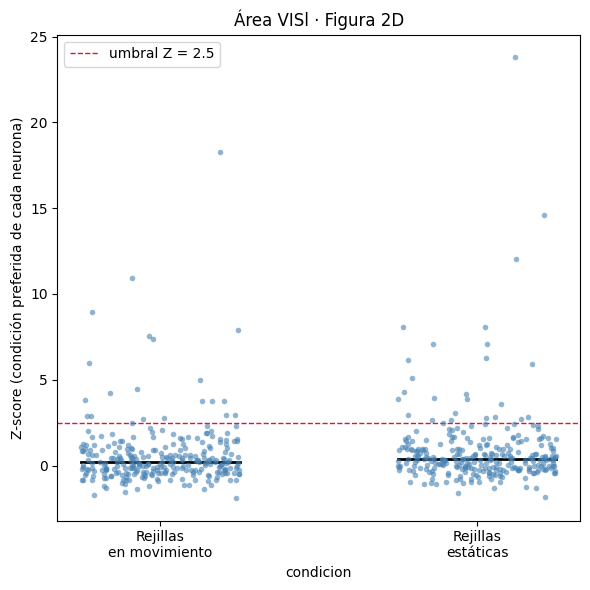

In [40]:
import seaborn as sns
import pandas as pd

# Define idx_static for 'static_gratings'
idx_static = np.where(e_clase_str == 'static_gratings')[0]

# Calculate evoked rates for drifting and static gratings
evoc_drift = tasa_evocada_ventana(idx_drifting, dur_por_clase['drifting_gratings'])
evoc_static = tasa_evocada_ventana(idx_static, dur_por_clase['static_gratings'])

# Calculate Z-scores for drifting and static gratings
z_drift = zscore(evoc_drift, mu_basal, sd_basal)

z_static = zscore(evoc_static, mu_basal, sd_basal)

z_por_condicion = {'drifting_gratings': z_drift, 'static_gratings': z_static}
etiquetas = {'drifting_gratings': 'Rejillas\nen movimiento', 'static_gratings': 'Rejillas\nestáticas'}

df_swarm = pd.concat([
    pd.DataFrame({'condicion': etiquetas[c], 'z': z_por_condicion[c]})
    for c in z_por_condicion
], ignore_index=True)

plt.figure(figsize=(6, 6))
sns.stripplot(data=df_swarm, x='condicion', y='z', size=4, alpha=0.6, jitter=0.25, color='steelblue')
for i, c in enumerate(z_por_condicion):
    med = np.nanmedian(z_por_condicion[c])
    plt.plot([i - 0.25, i + 0.25], [med, med], color='black', lw=2)
plt.axhline(UMBRAL_Z, color='crimson', linestyle='--', lw=1, label=f'umbral Z = {UMBRAL_Z}')
plt.ylabel('Z-score (condición preferida de cada neurona)')
plt.title(f'Área {MI_AREA} · Figura 2D')
plt.legend()
plt.tight_layout()
plt.show()

Figura2-E

Fracción respondedora, rejillas en movimiento: 0.072  IC95%[0.030, 0.152]
Fracción respondedora, rejillas estáticas:      0.090  IC95%[0.048, 0.181]
Diferencia (movimiento - estática):              -0.018  IC95%[-0.068, 0.018]

[Referencia] IC95% de la diferencia SIN jerarquía (ignora el ratón): [-0.061, 0.029]  (ancho: 0.090 vs 0.085 jerárquico)

Prueba de permutación (pareada por neurona): p = 0.3828
d de Cohen (pareado, sobre Z-score por neurona): -0.15


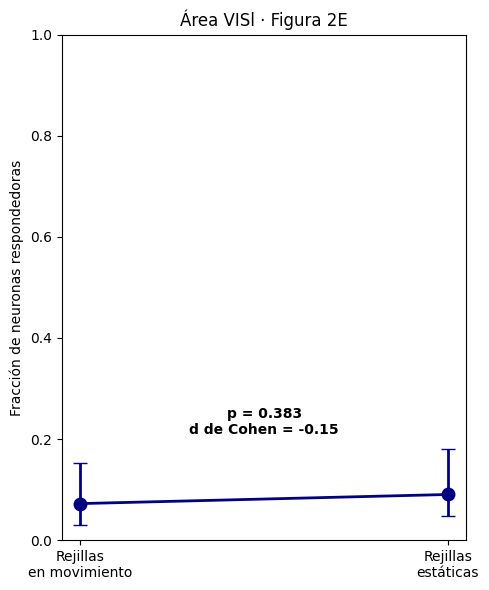

In [43]:
def tasa_por_ensayo_gen(idx_ensayos, t_fin, t_ini=0.0):
    """Igual que tasa_por_ensayo() del Paso 3, pero con ventana [t_ini, t_fin)
    configurable (Paso 3 la tenía fija en [0, 2) s). Matriz (n_neuronas x
    len(idx_ensayos)), con NaN donde esa neurona no vio ese ensayo."""
    n_cols = len(idx_ensayos)
    col_de_ensayo = np.full(n_ens_tot, -1, dtype=np.int64)
    col_de_ensayo[idx_ensayos] = np.arange(n_cols)
    col = col_de_ensayo[s_ensayo]
    usar = (col >= 0) & (s_t >= t_ini) & (s_t < t_fin)
    plano = s_unidad[usar] * n_cols + col[usar]
    cuentas = np.bincount(plano, minlength=n_neuronas * n_cols).reshape(n_neuronas, n_cols)
    tasa = cuentas / (t_fin - t_ini)
    vio = u_cod[:, None] == e_cod[idx_ensayos][None, :]
    return np.where(vio, tasa, np.nan)
tasa_ev_drift_full  = tasa_evocada
# static_gratings
tasa_ev_static_full = tasa_por_ensayo_gen(idx_static, dur_por_clase['static_gratings'])

ens_pref_drift = []
for i in range(n_neuronas):
    cols_condicion = np.where(etq == k_pref[i])[0]
    idx_ensayos_cond = idx_drifting[cols_val[cols_condicion]]
    ens_pref_drift.append(np.array([e for e in idx_ensayos_cond if e_raton[e] == u_raton[i]]))

ens_pref_static = [idx_static[e_raton[idx_static] == u_raton[i]] for i in range(n_neuronas)]

UMBRAL_Z = 2.5  # el mismo umbral que ya usaste y justificaste con los rasters

def ensayos_basales_por_neurona():
    """Lista, por neurona, de los índices (columnas de tasa_basal) de sus propios
    ensayos espontáneos."""
    return [np.where(~np.isnan(tasa_basal[i]))[0] for i in range(n_neuronas)]

ens_basal_por_neurona = ensayos_basales_por_neurona()

# valores crudos de tasa (Hz) por neurona, ya filtrados a SUS propios ensayos
basal_valores  = [tasa_basal[i, ens_basal_por_neurona[i]] for i in range(n_neuronas)]

def valores_condicion(idx_clase, tasa_full, ensayos_pref):
    """valores[i] = tasa evocada (Hz) de la neurona i en CADA uno de sus ensayos
    de su combinación preferida (arreglo 1D, longitud variable por neurona)."""
    col_de_idx = {e: j for j, e in enumerate(idx_clase)}
    valores = []
    for i in range(n_neuronas):
        cols = [col_de_idx[e] for e in ensayos_pref[i]]
        v = tasa_full[i, cols]
        valores.append(v[~np.isnan(v)])
    return valores

drift_valores = [
    tasa_ev_drift_full[i, ~np.isnan(tasa_ev_drift_full[i])]
    for i in range(n_neuronas)
]

# Todas las rejillas estáticas
static_valores = [
    tasa_ev_static_full[i, ~np.isnan(tasa_ev_static_full[i])]
    for i in range(n_neuronas)
]

# neurona -> índice de ratón (0..4), para el nivel 1 del bootstrap
neurona_a_raton = u_cod.copy()
ratones_cod_unicos = np.unique(u_cod)

# neuronas agrupadas por ratón (para remuestrear neuronas dentro de cada ratón)
neuronas_por_raton = {r: np.where(u_cod == r)[0] for r in ratones_cod_unicos}

def fraccion_respondedora(neuronas_idx, cond_valores, rng):
    """neuronas_idx: array de índices de neurona (con repetición, resultado del
    remuestreo de niveles 1-2). Para cada una, remuestrea sus propios ensayos
    (nivel 3) con reemplazo y calcula si responde."""
    resp = np.zeros(len(neuronas_idx), dtype=bool)
    for j, i in enumerate(neuronas_idx):
        b = basal_valores[i]
        e = cond_valores[i]
        if len(b) == 0 or len(e) == 0:
            resp[j] = False
            continue
        b_boot = rng.choice(b, size=len(b), replace=True)
        e_boot = rng.choice(e, size=len(e), replace=True)
        sd = b_boot.std(ddof=0)
        if sd == 0:
            resp[j] = False
            continue
        z = (e_boot.mean() - b_boot.mean()) / sd
        resp[j] = z >= UMBRAL_Z
    return resp.mean()

N_BOOT = 10_000
rng = np.random.default_rng(0)

frac_drift_boot  = np.empty(N_BOOT)
frac_static_boot = np.empty(N_BOOT)

for b in range(N_BOOT):
    # Nivel 1: ratones con reemplazo
    ratones_boot = rng.choice(ratones_cod_unicos, size=len(ratones_cod_unicos), replace=True)

    neuronas_replica = []
    for r in ratones_boot:
        neuronas_r = neuronas_por_raton[r]
        # Nivel 2: neuronas de ESE ratón, con reemplazo, mismo tamaño original
        neuronas_replica.append(rng.choice(neuronas_r, size=len(neuronas_r), replace=True))
    neuronas_replica = np.concatenate(neuronas_replica)

    # Nivel 3 (ensayos) ocurre DENTRO de fraccion_respondedora
    frac_drift_boot[b]  = fraccion_respondedora(neuronas_replica, drift_valores, rng)
    frac_static_boot[b] = fraccion_respondedora(neuronas_replica, static_valores, rng)

diff_boot = frac_drift_boot - frac_static_boot

ic_drift  = np.percentile(frac_drift_boot,  [2.5, 97.5])
ic_static = np.percentile(frac_static_boot, [2.5, 97.5])
ic_diff   = np.percentile(diff_boot,        [2.5, 97.5])
frac_drift_obs  = (z_drift  >= UMBRAL_Z).mean()
frac_static_obs = (z_static >= UMBRAL_Z).mean()

print(f"Fracción respondedora, rejillas en movimiento: {frac_drift_obs:.3f}  IC95%[{ic_drift[0]:.3f}, {ic_drift[1]:.3f}]")
print(f"Fracción respondedora, rejillas estáticas:      {frac_static_obs:.3f}  IC95%[{ic_static[0]:.3f}, {ic_static[1]:.3f}]")
print(f"Diferencia (movimiento - estática):              {frac_drift_obs-frac_static_obs:.3f}  IC95%[{ic_diff[0]:.3f}, {ic_diff[1]:.3f}]")
from scipy import stats
resp_drift_bin  = (z_drift  >= UMBRAL_Z).astype(float)
resp_static_bin = (z_static >= UMBRAL_Z).astype(float)
t_stat, p_ttest = stats.ttest_rel(resp_drift_bin, resp_static_bin)
# IC ingenuo vía bootstrap plano (sin jerarquía), para comparar anchos
rng2 = np.random.default_rng(1)
diff_flat_boot = np.array([
    (rng2.choice(resp_drift_bin, n_neuronas, replace=True).mean()
     - rng2.choice(resp_static_bin, n_neuronas, replace=True).mean())
    for _ in range(N_BOOT)
])
ic_diff_flat = np.percentile(diff_flat_boot, [2.5, 97.5])
print(f"\n[Referencia] IC95% de la diferencia SIN jerarquía (ignora el ratón): "
      f"[{ic_diff_flat[0]:.3f}, {ic_diff_flat[1]:.3f}]  (ancho: {ic_diff_flat[1]-ic_diff_flat[0]:.3f} "
      f"vs {ic_diff[1]-ic_diff[0]:.3f} jerárquico)")

N_PERM = 10_000
diff_obs = frac_drift_obs - frac_static_obs
rng3 = np.random.default_rng(2)
diffs_perm = np.empty(N_PERM)
for p in range(N_PERM):
    swap = rng3.random(n_neuronas) < 0.5
    a = np.where(swap, resp_static_bin, resp_drift_bin)
    bb = np.where(swap, resp_drift_bin, resp_static_bin)
    diffs_perm[p] = a.mean() - bb.mean()
p_valor = (np.abs(diffs_perm) >= np.abs(diff_obs)).mean()
print(f"\nPrueba de permutación (pareada por neurona): p = {p_valor:.4f}")

# d de Cohen (pareado)
diff_por_neurona = z_drift - z_static
d_cohen = np.nanmean(diff_por_neurona) / np.nanstd(diff_por_neurona, ddof=1)
print(f"d de Cohen (pareado, sobre Z-score por neurona): {d_cohen:.2f}")

plt.figure(figsize=(5, 6))
x = [0, 1]
y_obs = [frac_drift_obs, frac_static_obs]
yerr_low  = [frac_drift_obs - ic_drift[0], frac_static_obs - ic_static[0]]
yerr_high = [ic_drift[1] - frac_drift_obs, ic_static[1] - frac_static_obs]

plt.errorbar(x, y_obs, yerr=[yerr_low, yerr_high], fmt='o-', color='navy',
             markersize=9, linewidth=2, capsize=5)
plt.xticks(x, ['Rejillas\nen movimiento', 'Rejillas\nestáticas'])
plt.ylabel('Fracción de neuronas respondedoras')
plt.ylim(0, 1)
plt.title(f'Área {MI_AREA} · Figura 2E')
texto_p = f"p = {p_valor:.3f}" if p_valor >= 0.001 else "p < 0.001"
plt.text(0.5, max(y_obs) + 0.12, f"{texto_p}\nd de Cohen = {d_cohen:.2f}",
          ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()